In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [5]:
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [2]:
from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.behaviour import navigation_strategies as ns
from GridMaze.maze import plotting as mp
from GridMaze.maze import representations as mr

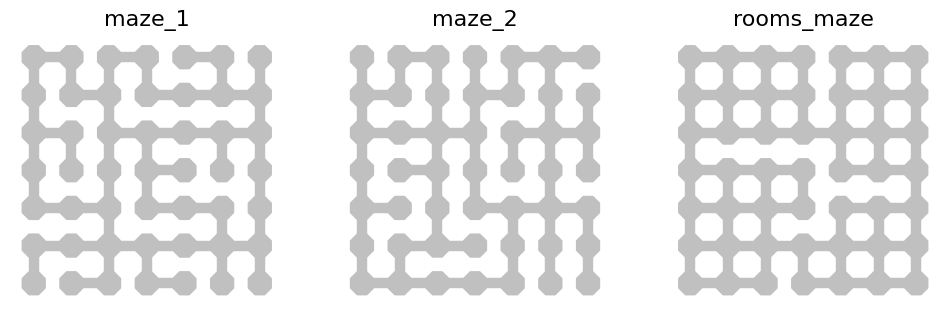

In [44]:
f1, axes = plt.subplots(1, 3, figsize=(12, 4), clear=True)
mp.plot_maze_series(axes)
f1.savefig("../results/behaviour/mazes.pdf")

In [3]:
basic_behaviour_df = pm.get_basic_behaviour_df()
strategy_weights_df = ns.get_strategy_weights_across_subjects()

navigation_strategies.parquet not found for m8.2022-07-26.maze


                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         trial    
No. Observations:           210             Method:                     ML       
No. Groups:                 6               Scale:                      105.9163 
Min. group size:            35              Log-Likelihood:             -795.6073
Max. group size:            35              Converged:                  Yes      
Mean group size:            35.0                                                 
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                               6.968    3.604  1.933 0.053 -0.097 14.033
C(maze_name)[T.maze_2]                 41.626    3.673 11.332 0.000 34.427 48.825
C(maze_name)[T.rooms_maze]            

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                       Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         n_excess_steps
No. Observations:         210             Method:                     ML            
No. Groups:               6               Scale:                      12.7442       
Min. group size:          35              Log-Likelihood:             -565.2101     
Max. group size:          35              Converged:                  Yes           
Mean group size:          35.0                                                      
------------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                               13.135    0.857  15.318 0.000  11.454 14.815
C(maze_name)[T.maze_2]                  -8.168    1.274  -6.410 0.000 -10.665 -5.671
C(ma

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


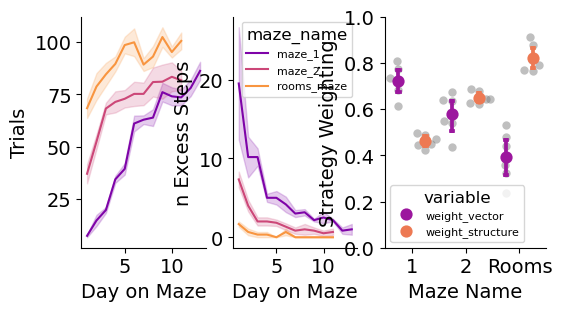

In [ ]:
from importlib import reload

reload(ns)
f2, axes = plt.subplots(1, 3, figsize=(6, 3), clear=True, width_ratios=[1, 1, 1.3])
# performance metrics
pm._plot_trials(basic_behaviour_df, ax=axes[0], legend=False, cmap="plasma")
pm._plot_n_excess_steps(basic_behaviour_df, ax=axes[1], legend=True, cmap="plasma")
# plot mixture of strategies model results (late session, random effects)
ns.plot_strategy_weights_cross_subject(
    strategy_weights_df, mazes=["maze_1", "maze_2", "rooms_maze"], ax=axes[2], colormap="plasma"
)
# f2.tight_layout()
f2.savefig("../results/behaviour/performance.pdf")

In [8]:
strategy_weights_bootstrapped = ns.get_strategy_weights_across_sessions()

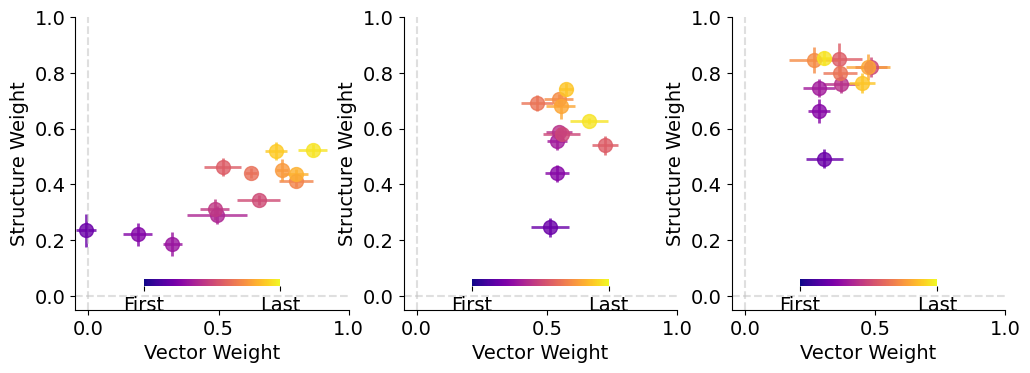

In [9]:
f3, axes = plt.subplots(1, 3, figsize=(12, 4))
from importlib import reload

reload(ns)
ns.plot_nav_strategy_weights_over_sessions(strategy_weights_bootstrapped, cmap="plasma", fig=f3, axes=axes)
f3.savefig("../results/behaviour/strategy_weights.pdf")